
Assignment 4 - Neural Network Classifier
As part of Module 11, 
   1. Import Libraries Np, Plt

In [1]:
import numpy as np
import matplotlib.pyplot as plt


2️. Define Binary Patterns for Letters A, B, and C

  * Each image is a 5×6
(30-pixel) grid encoded as a 1D array

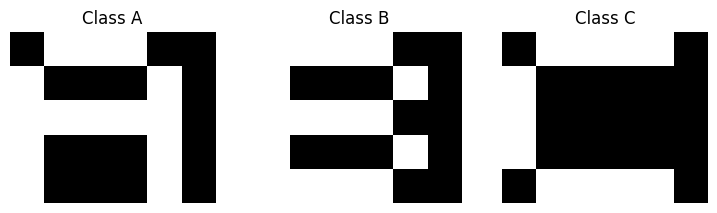

In [3]:
# Define binary images for A, B, C (5x6 grids)
A = np.array([
    [0,1,1,1,0,0],
    [1,0,0,0,1,0],
    [1,1,1,1,1,0],
    [1,0,0,0,1,0],
    [1,0,0,0,1,0]
]).flatten()

B = np.array([
    [1,1,1,1,0,0],
    [1,0,0,0,1,0],
    [1,1,1,1,0,0],
    [1,0,0,0,1,0],
    [1,1,1,1,0,0]
]).flatten()

C = np.array([
    [0,1,1,1,1,0],
    [1,0,0,0,0,0],
    [1,0,0,0,0,0],
    [1,0,0,0,0,0],
    [0,1,1,1,1,0]
]).flatten()

# Stack into training data
X = np.array([A, B, C])   # shape (3, 30)
y = np.array([
    [1,0,0],   # A → class 0
    [0,1,0],   # B → class 1
    [0,0,1]    # C → class 2
])             # one-hot encoded
num_classes = y.shape[1]
# Visualize the images
fig, axs = plt.subplots(1, 3, figsize=(9, 3))   
for i, (img, label) in enumerate(zip(X, ['A', 'B', 'C'])):
    axs[i].imshow(img.reshape(5,6), cmap='gray')
    axs[i].set_title(f'Class {label}')
    axs[i].axis('off')
plt.show()
# Neural Network Parameters

3. Define Helper Functions
    

In [5]:
# Sigmoid activation and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Mean Squared Error (MSE) Loss
def mse(y_true, y_pred):
    return np.mean(np.square(y_true - y_pred))


4. Initialize Network Parameters

We’ll use:

     * 30 input neurons (pixels)

     * 8 hidden neurons

     * 3 output neurons (A, B, C classes)

In [6]:
np.random.seed(42)

input_size = 30
hidden_size = 8
output_size = 3

# Random weight initialization
W1 = np.random.uniform(-1, 1, (input_size, hidden_size))
b1 = np.zeros((1, hidden_size))

W2 = np.random.uniform(-1, 1, (hidden_size, output_size))
b2 = np.zeros((1, output_size))


4. Training Loop (Forward + Backpropagation)

In [7]:
epochs = 5000
learning_rate = 0.1
loss_history = []

for epoch in range(epochs):
    # ---- Forward pass ----
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    output = sigmoid(z2)
    
    # ---- Loss ----
    loss = mse(y, output)
    loss_history.append(loss)
    
    # ---- Backpropagation ----
    error = y - output
    d_output = error * sigmoid_derivative(output)
    
    error_hidden = np.dot(d_output, W2.T)
    d_hidden = error_hidden * sigmoid_derivative(a1)
    
    # ---- Update weights and biases ----
    W2 += np.dot(a1.T, d_output) * learning_rate
    b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate
    W1 += np.dot(X.T, d_hidden) * learning_rate
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate
    
    # Print progress occasionally
    if (epoch+1) % 500 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.6f}")


Epoch 500/5000 - Loss: 0.012675
Epoch 1000/5000 - Loss: 0.004587
Epoch 1500/5000 - Loss: 0.002614
Epoch 2000/5000 - Loss: 0.001786
Epoch 2500/5000 - Loss: 0.001342
Epoch 3000/5000 - Loss: 0.001069
Epoch 3500/5000 - Loss: 0.000886
Epoch 4000/5000 - Loss: 0.000754
Epoch 4500/5000 - Loss: 0.000656
Epoch 5000/5000 - Loss: 0.000580


5. Visualize Training Loss

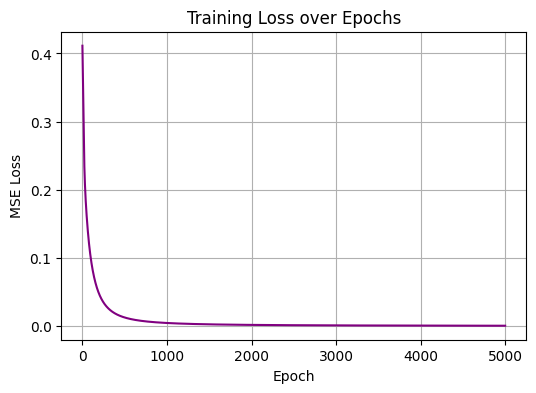

In [8]:
plt.figure(figsize=(6,4))
plt.plot(loss_history, color='purple')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


6. Testing & Predictions

In [9]:
# Forward pass for prediction
def predict(X_input):
    a1 = sigmoid(np.dot(X_input, W1) + b1)
    output = sigmoid(np.dot(a1, W2) + b2)
    return output

preds = predict(X)
pred_classes = np.argmax(preds, axis=1)

print("Predicted classes:", pred_classes)
print("Expected classes: [0, 1, 2]")        


Predicted classes: [0 1 2]
Expected classes: [0, 1, 2]


7. Display the Letter Images with Predictions

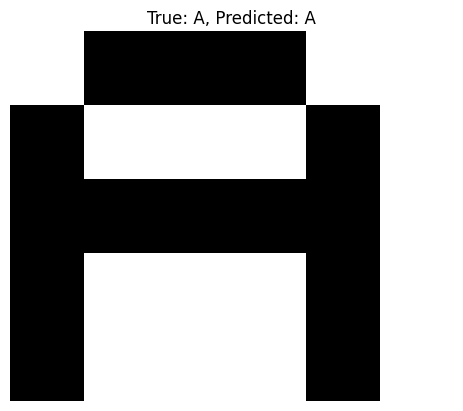

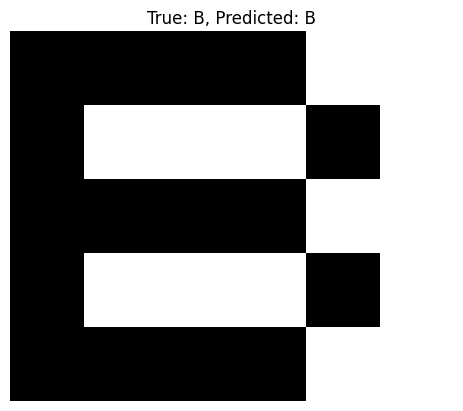

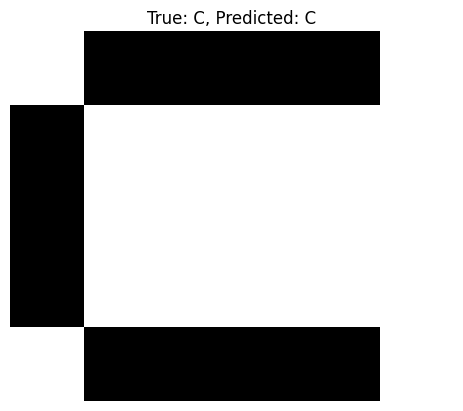

In [10]:
letters = ['A', 'B', 'C']

for i, img in enumerate(X):
    plt.figure()
    plt.imshow(img.reshape(5,6), cmap='gray_r')
    plt.title(f"True: {letters[i]}, Predicted: {letters[pred_classes[i]]}")
    plt.axis('off')
    plt.show()
